`tz_fornacis_data_1000.pkl` vs HARPS — narrow-band (5000–5010 Å) comparison\n\nThis notebook overlays the 1000-wavelength SPICE pickle of TZ Fornacis (`tz_fornacis_data_1000.pkl`,\n230 orbital phases over 5000–5010 Å) on the HARPS exposures stored in\n`harps_data_zarr2.zarr` (21 SUPPNet-normalized exposures, 3781–6913 Å).\n\nEach SPICE entry holds `(line_flux, continuum)` columns, so the comparable signal is\n`normalized = s[:, 0] / s[:, 1]`. HARPS phases (`phases` array in days) are folded by the\n75.666 47 d Gallenne+2016 period; the SPICE side uses `mean_anomaly_at_t0_rad` from\n`binary_params` to align with the same T_p epoch.\n\nThe window is too narrow for the broad-band CCF/diagnostics in\n`harps_spice_diagnostics.py`, so this notebook focuses on:\n\n1. Phase-matching every HARPS exposure to its nearest SPICE phase.\n2. Direct overlay of HARPS vs SPICE composite (body1 + body2) per exposure.\n3. Phase-sorted residual waterfall.\n4. Narrow-band CCF bulk-RV across phase.\n5. A zoom on the strongest Fe I features in this window (5006.119, 5007.270).
6. **RV-aligned overlays** — shift each SPICE spectrum by the narrow-band CCF peak before plotting, isolating line-shape residuals from bulk frame error.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import sys
import pickle
from pathlib import Path

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import zarr
from scipy.signal import correlate


def _repo_root(here: Path) -> Path:
    for p in [here, *here.parents]:
        if (p / "src" / "spice").is_dir():
            return p
    raise RuntimeError("Could not find spice repo root (src/spice)")


HERE = Path.cwd()
REPO = _repo_root(HERE)
SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from spice.spectrum import apply_spectral_resolution

C_KMS = 299_792.458
P_DAYS = 75.66647

# Pickle location: workspace root by default, override via TZ_FOR_PICKLE env var.
PICKLE_PATH = Path(os.environ.get(
    "TZ_FOR_PICKLE",
    str(REPO / "tz_fornacis_data_1000.pkl"),
))
HARPS_ZARR_PATH = REPO / "tutorial" / "paper_results" / "tz_fornacis" / "harps_data_zarr2.zarr"

print(f"REPO         : {REPO}")
print(f"PICKLE_PATH  : {PICKLE_PATH}  (exists={PICKLE_PATH.exists()})")
print(f"HARPS_ZARR   : {HARPS_ZARR_PATH}  (exists={HARPS_ZARR_PATH.exists()})")

REPO         : /Users/mjablons/code/spice
PICKLE_PATH  : /Users/mjablons/code/spice/tz_fornacis_data_1000.pkl  (exists=True)
HARPS_ZARR   : /Users/mjablons/code/spice/tutorial/paper_results/tz_fornacis/harps_data_zarr2.zarr  (exists=True)


## Load the SPICE pickle and HARPS zarr, match by orbital phase

In [2]:
with open(PICKLE_PATH, "rb") as f:
    data = pickle.load(f)

PERIOD_YR = float(data["period_yr"])
BINARY_PARAMS = data["binary_params"]
times_yr = np.asarray(data["times"])
wavelengths_spice = np.asarray(data["wavelengths"])
spectra1 = np.asarray(data["spectra_body1"])
spectra2 = np.asarray(data["spectra_body2"])
WL_LO = float(data["wl_min"])
WL_HI = float(data["wl_max"])


def spice_orbital_phase(times_yr, binary_params=BINARY_PARAMS, period_yr=PERIOD_YR):
    """SPICE t=0 → Gallenne-T_p orbital phase, modulo 1."""
    m0 = float(binary_params["mean_anomaly_at_t0_rad"])
    return (np.asarray(times_yr) / period_yr + m0 / (2.0 * np.pi)) % 1.0


SPICE_PHASES = spice_orbital_phase(times_yr)

harps = zarr.open_group(str(HARPS_ZARR_PATH))
HARPS_PHASES_DAYS = np.asarray(harps["phases"][:])
HARPS_PHASES = HARPS_PHASES_DAYS / P_DAYS

# For each HARPS exposure, find the closest SPICE phase (wrap-around aware).
_delta = np.abs(SPICE_PHASES[None, :] - HARPS_PHASES[:, None])
_delta = np.minimum(_delta, 1.0 - _delta)
SPICE_MATCH_IDX = np.argmin(_delta, axis=1)
MATCH_DPHASE = _delta[np.arange(len(HARPS_PHASES)), SPICE_MATCH_IDX]

print(f"SPICE: {len(times_yr)} phases over {WL_LO:.1f}–{WL_HI:.1f} Å, "
      f"{wavelengths_spice.size} wavelength samples")
print(f"HARPS: {len(HARPS_PHASES)} exposures (phases {HARPS_PHASES_DAYS.min():.2f}–"
      f"{HARPS_PHASES_DAYS.max():.2f} d, normalized {HARPS_PHASES.min():.3f}–"
      f"{HARPS_PHASES.max():.3f})")
print(f"Phase-match residual: median |Δφ| = {np.median(MATCH_DPHASE):.4f} "
      f"(median Δt ≈ {np.median(MATCH_DPHASE) * P_DAYS * 24:.2f} h)")
print(f"binary_params summary:")
for k in ("primary_teff", "secondary_teff", "primary_radius", "secondary_radius",
          "gamma_kms", "mean_anomaly_at_t0_rad"):
    print(f"  {k:>26s} = {BINARY_PARAMS[k]}")

SPICE: 230 phases over 5000.0–5010.0 Å, 1000 wavelength samples
HARPS: 21 exposures (phases 4.99–72.20 d, normalized 0.066–0.954)
Phase-match residual: median |Δφ| = 0.0017 (median Δt ≈ 3.16 h)
binary_params summary:
                primary_teff = 4930
              secondary_teff = 6650
              primary_radius = 8.28
            secondary_radius = 3.94
                   gamma_kms = 18.16556164383562
      mean_anomaly_at_t0_rad = 1.5165057113596


## Phase alignment plot

Where each HARPS exposure falls on the orbit and which SPICE phase it gets matched to.
Eclipse windows (from `binary_params`) are shaded so we can immediately see which
exposures are in/out of eclipse.

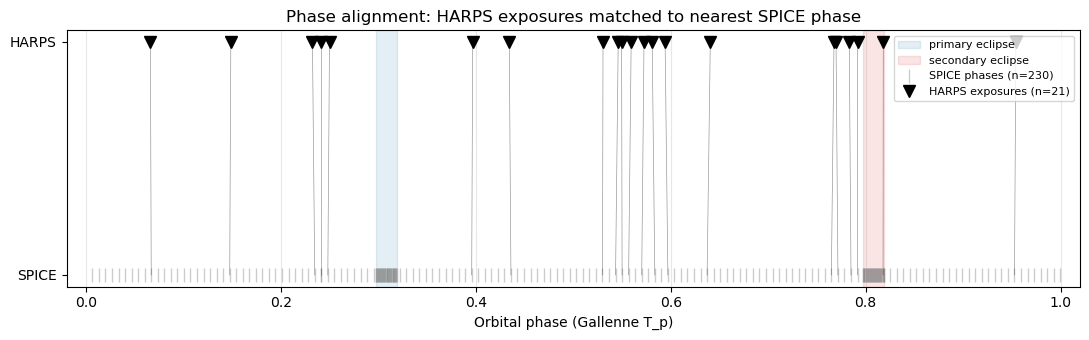

|Δφ| matched: min=0.00000, median=0.00174, max=0.00327
|Δt| matched: median=3.16 h, max=5.93 h


In [3]:
prim_win = data["primary_eclipse_window_yr"]
sec_win = data["secondary_eclipse_window_yr"]
prim_phase_win = tuple(spice_orbital_phase(np.asarray(prim_win)))
sec_phase_win = tuple(spice_orbital_phase(np.asarray(sec_win)))

fig, ax = plt.subplots(figsize=(11, 3.5))
for lo, hi, name, color in [
    (*prim_phase_win, "primary eclipse", "tab:blue"),
    (*sec_phase_win, "secondary eclipse", "tab:red"),
]:
    if lo <= hi:
        ax.axvspan(lo, hi, color=color, alpha=0.12, label=name)
    else:
        ax.axvspan(lo, 1.0, color=color, alpha=0.12, label=name)
        ax.axvspan(0.0, hi, color=color, alpha=0.12)

ax.plot(SPICE_PHASES, np.full_like(SPICE_PHASES, 0.0), "|",
        color="gray", ms=10, alpha=0.4, label=f"SPICE phases (n={len(SPICE_PHASES)})")
ax.plot(HARPS_PHASES, np.full_like(HARPS_PHASES, 1.0), "v",
        color="black", ms=8, label=f"HARPS exposures (n={len(HARPS_PHASES)})")
for hph, sidx in zip(HARPS_PHASES, SPICE_MATCH_IDX):
    sph = SPICE_PHASES[sidx]
    dx = sph - hph
    if abs(dx) > 0.5:
        dx -= np.sign(dx)
    ax.plot([hph, hph + dx], [1.0, 0.0], color="black", lw=0.5, alpha=0.4)

ax.set_xlim(-0.02, 1.02)
ax.set_yticks([0, 1], ["SPICE", "HARPS"])
ax.set_xlabel("Orbital phase (Gallenne T_p)")
ax.set_title("Phase alignment: HARPS exposures matched to nearest SPICE phase")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(f"|Δφ| matched: min={MATCH_DPHASE.min():.5f}, "
      f"median={np.median(MATCH_DPHASE):.5f}, "
      f"max={MATCH_DPHASE.max():.5f}")
print(f"|Δt| matched: median={np.median(MATCH_DPHASE) * P_DAYS * 24:.2f} h, "
      f"max={MATCH_DPHASE.max() * P_DAYS * 24:.2f} h")

## Resample HARPS and SPICE onto a common log-uniform grid

Both spectra are degraded to the same resolution (R = 60 000) so we compare like-for-like.
The SPICE composite is `(s1[:, 0] + s2[:, 0]) / (s1[:, 1] + s2[:, 1])`, which is the
luminosity-weighted normalized spectrum of the binary.

In [4]:
# Slight inset from the pickle edges to avoid SPICE boundary artefacts during convolution.
WIN_LO = WL_LO + 0.5
WIN_HI = WL_HI - 0.5
N_COMMON = 2048
LOG_WL = np.linspace(np.log10(WIN_LO), np.log10(WIN_HI), N_COMMON)
WAVE = 10.0 ** LOG_WL
V_PER_PIXEL = (LOG_WL[1] - LOG_WL[0]) * np.log(10.0) * C_KMS

R_DEGRADE = 60_000.0


def spice_composite_norm(idx):
    s1 = spectra1[idx]
    s2 = spectra2[idx]
    line = s1[:, 0] + s2[:, 0]
    cont = s1[:, 1] + s2[:, 1]
    return line / cont


def degrade(flux_on_wave, R=R_DEGRADE):
    return np.asarray(
        apply_spectral_resolution(jnp.asarray(LOG_WL), jnp.asarray(flux_on_wave), R)
    )


def harps_on_common(i):
    hw = np.asarray(harps["normalized_wave"][i])
    hf = np.asarray(harps["normalized_flux"][i])
    m = np.isfinite(hw) & np.isfinite(hf) & (hw >= WIN_LO - 1.0) & (hw <= WIN_HI + 1.0)
    return degrade(np.interp(WAVE, hw[m], hf[m]))


def spice_on_common(sidx):
    f = spice_composite_norm(sidx)
    return degrade(np.interp(WAVE, wavelengths_spice, f))


harps_grid = np.stack([harps_on_common(i) for i in range(len(HARPS_PHASES))])
spice_grid = np.stack([spice_on_common(int(s)) for s in SPICE_MATCH_IDX])

print(f"Common log-λ grid: {WIN_LO:.2f}–{WIN_HI:.2f} Å, {N_COMMON} samples,"
      f" ΔV ≈ {V_PER_PIXEL:.3f} km/s/pix, R_degrade = {R_DEGRADE:.0f}")
print(f"harps_grid shape: {harps_grid.shape}  spice_grid shape: {spice_grid.shape}")

Common log-λ grid: 5000.50–5009.50 Å, 2048 samples, ΔV ≈ 0.263 km/s/pix, R_degrade = 60000
harps_grid shape: (21, 2048)  spice_grid shape: (21, 2048)


## Per-exposure overlay

Each panel shows one HARPS exposure (black) and its phase-matched SPICE composite (red),
plus the HARPS−SPICE residual (blue, offset to −0.2 for visibility).

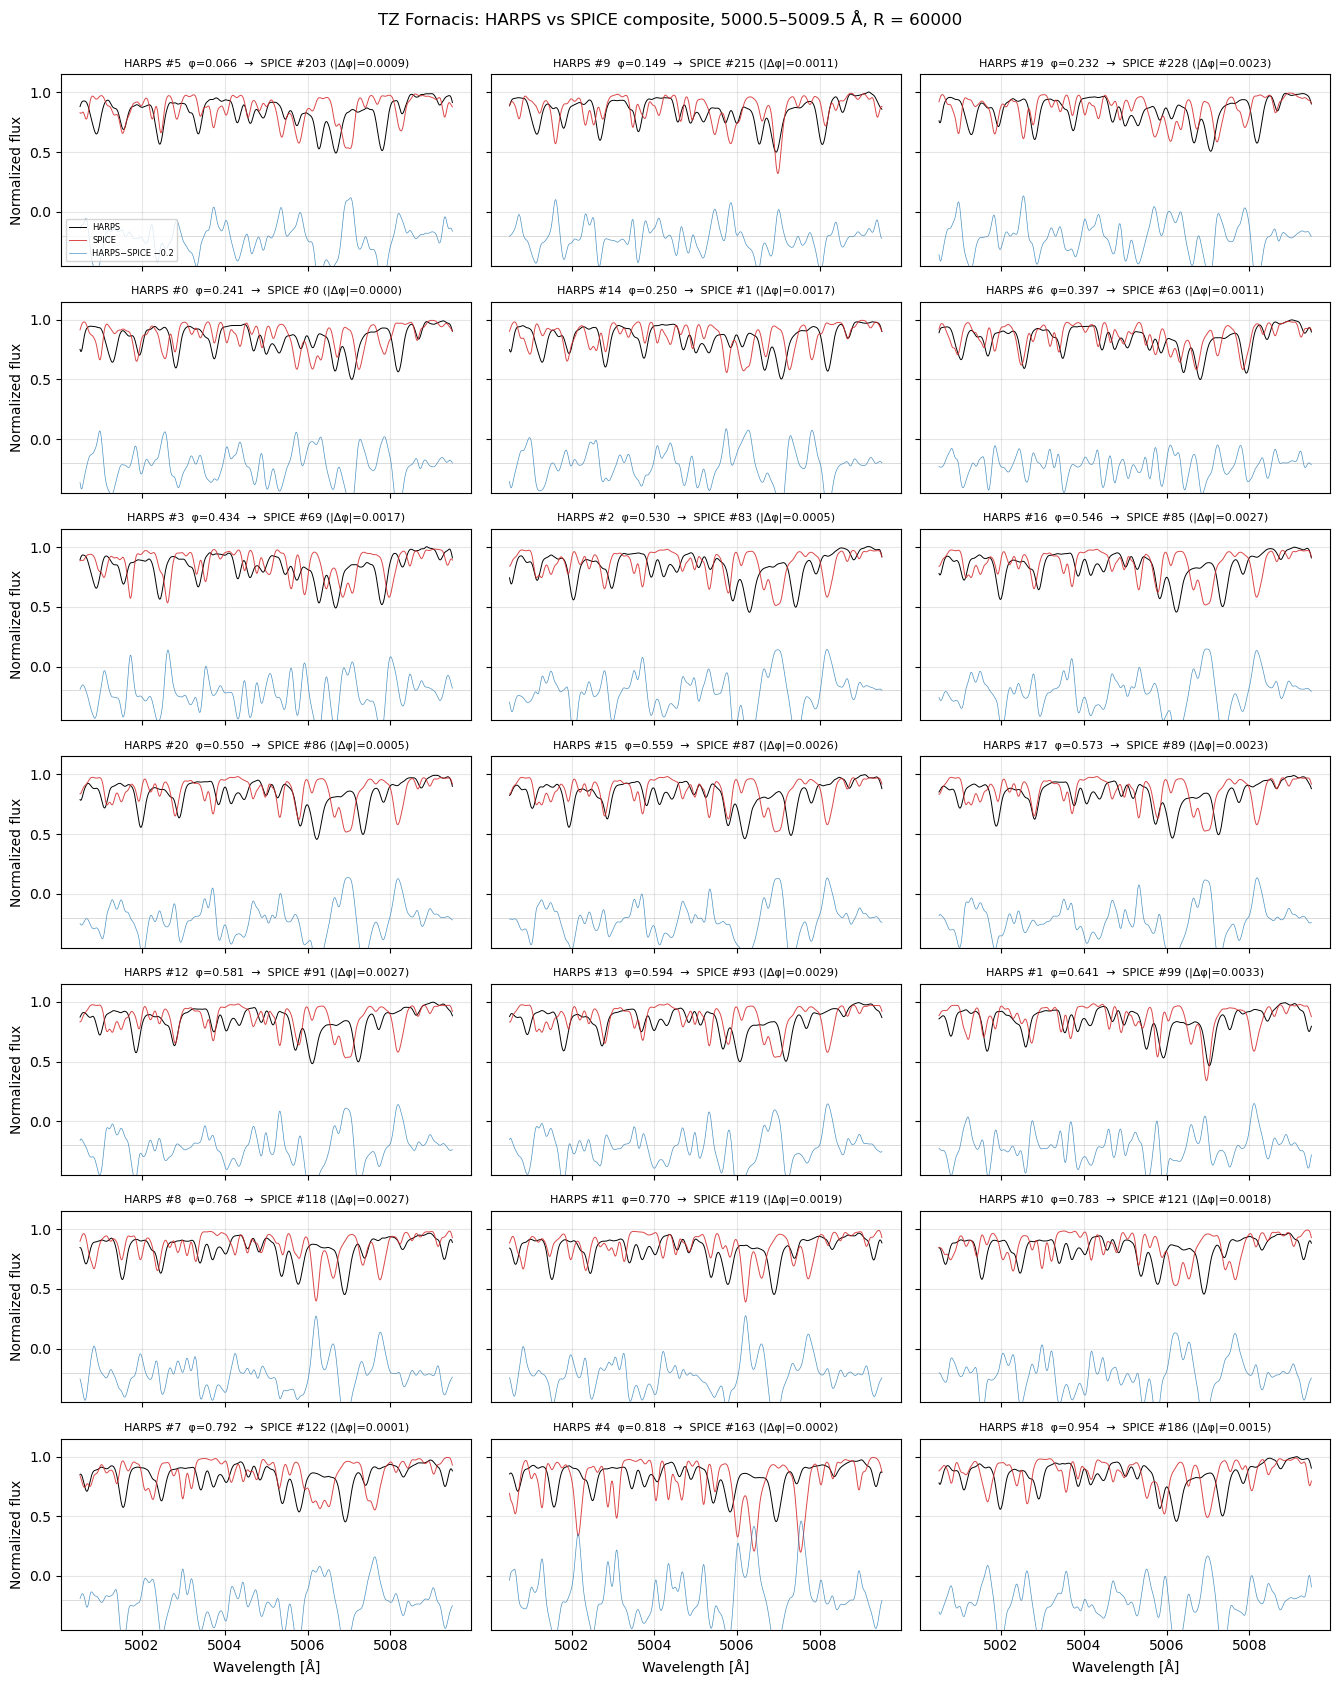

In [5]:
order = np.argsort(HARPS_PHASES)
n_panels = len(order)
n_cols = 3
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 2.4 * n_rows),
                         sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for ax_idx, i in enumerate(order):
    ax = axes.flat[ax_idx]
    h = harps_grid[i]
    s = spice_grid[i]
    r = h - s
    ax.plot(WAVE, h, color="black", lw=0.7, label="HARPS")
    ax.plot(WAVE, s, color="tab:red", lw=0.7, alpha=0.85, label="SPICE")
    ax.plot(WAVE, r - 0.2, color="tab:blue", lw=0.5, alpha=0.8, label="HARPS−SPICE −0.2")
    ax.axhline(-0.2, color="gray", lw=0.4, alpha=0.5)
    ax.set_title(
        f"HARPS #{i}  φ={HARPS_PHASES[i]:.3f}  →  SPICE #{SPICE_MATCH_IDX[i]} "
        f"(|Δφ|={MATCH_DPHASE[i]:.4f})",
        fontsize=8,
    )
    ax.set_ylim(-0.45, 1.15)
    ax.grid(alpha=0.3)
    if ax_idx == 0:
        ax.legend(fontsize=6, loc="lower left")

for j in range(n_panels, axes.size):
    axes.flat[j].axis("off")

for ax in axes[-1]:
    ax.set_xlabel("Wavelength [Å]")
for ax in axes[:, 0]:
    ax.set_ylabel("Normalized flux")

plt.suptitle(
    f"TZ Fornacis: HARPS vs SPICE composite, {WIN_LO:.1f}–{WIN_HI:.1f} Å, "
    f"R = {R_DEGRADE:.0f}",
    y=1.0,
)
plt.tight_layout()
plt.show()

## Phase-sorted waterfall

HARPS, SPICE, and the residual stacked vertically and sorted by orbital phase. Eclipse
windows are shaded. Vertical stripes in the residual = wavelength-coherent error
(continuum / sampling / RV offset); horizontal stripes = exposures where the model is
systematically off.

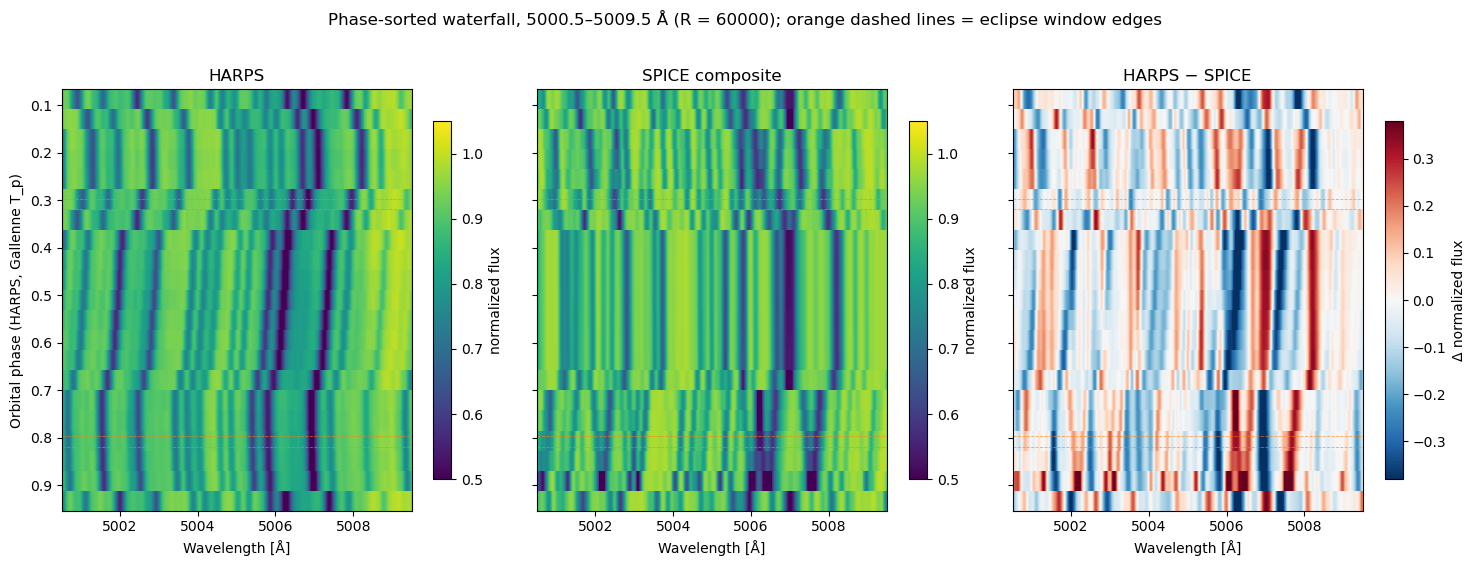

Residual stats (HARPS − SPICE, all pixels):
  mean   = -0.0206
  median = -0.0159
  std    = 0.1461
  RMS    = 0.1475


In [6]:
order_phase = np.argsort(HARPS_PHASES)
phases_sorted = HARPS_PHASES[order_phase]
H_sorted = harps_grid[order_phase]
S_sorted = spice_grid[order_phase]
R_sorted = H_sorted - S_sorted

extent = (WIN_LO, WIN_HI, phases_sorted[-1], phases_sorted[0])

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
imH = axes[0].imshow(H_sorted, aspect="auto", extent=extent, cmap="viridis",
                     vmin=0.5, vmax=1.05, interpolation="nearest")
axes[0].set_title("HARPS")
fig.colorbar(imH, ax=axes[0], shrink=0.85, label="normalized flux")

imS = axes[1].imshow(S_sorted, aspect="auto", extent=extent, cmap="viridis",
                     vmin=0.5, vmax=1.05, interpolation="nearest")
axes[1].set_title("SPICE composite")
fig.colorbar(imS, ax=axes[1], shrink=0.85, label="normalized flux")

vmax_r = float(np.nanpercentile(np.abs(R_sorted), 98))
imR = axes[2].imshow(R_sorted, aspect="auto", extent=extent, cmap="RdBu_r",
                     vmin=-vmax_r, vmax=vmax_r, interpolation="nearest")
axes[2].set_title("HARPS − SPICE")
fig.colorbar(imR, ax=axes[2], shrink=0.85, label="Δ normalized flux")

for ax in axes:
    ax.set_xlabel("Wavelength [Å]")
    for lo, hi in (prim_phase_win, sec_phase_win):
        if lo <= hi:
            ax.axhspan(lo, hi, color="tab:orange", alpha=0.0, lw=0)
            ax.axhline(lo, color="tab:orange", lw=0.6, ls="--", alpha=0.7)
            ax.axhline(hi, color="tab:orange", lw=0.6, ls="--", alpha=0.7)
        else:
            ax.axhline(lo, color="tab:orange", lw=0.6, ls="--", alpha=0.7)
            ax.axhline(hi, color="tab:orange", lw=0.6, ls="--", alpha=0.7)
axes[0].set_ylabel("Orbital phase (HARPS, Gallenne T_p)")

plt.suptitle(
    f"Phase-sorted waterfall, {WIN_LO:.1f}–{WIN_HI:.1f} Å (R = {R_DEGRADE:.0f}); "
    f"orange dashed lines = eclipse window edges",
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"Residual stats (HARPS − SPICE, all pixels):")
print(f"  mean   = {R_sorted.mean():+.4f}")
print(f"  median = {np.median(R_sorted):+.4f}")
print(f"  std    = {R_sorted.std():.4f}")
print(f"  RMS    = {np.sqrt(np.mean(R_sorted**2)):.4f}")

## Narrow-band CCF: bulk RV per exposure

CCF of each HARPS exposure against its phase-matched SPICE composite, on the same
log-λ grid (so a CCF pixel = a constant Δv). The peak gives the bulk RV offset
HARPS − SPICE per exposure. A clean comparison should show small, structureless
residuals; a coherent sinusoid in φ → mis-applied per-body Doppler.

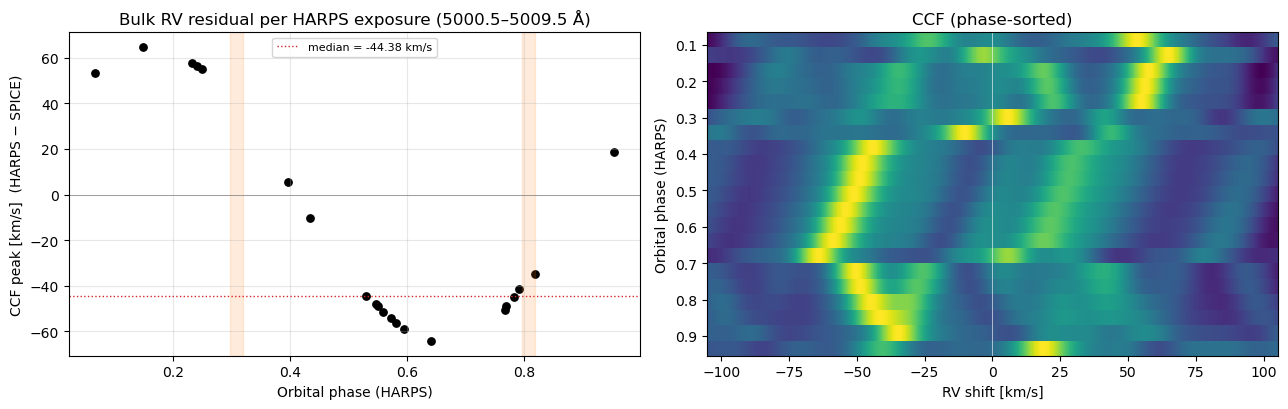

HARPS − SPICE bulk-RV (narrow-band CCF):
  mean   = -16.52 km/s
  median = -44.38 km/s
  std    = 45.86 km/s
  min/max= -64.21 / +64.70 km/s


In [7]:
MAX_LAG_PIX = 400  # ±400 px = ±~24 km/s, plenty for the residual shift
LAGS = np.arange(-MAX_LAG_PIX, MAX_LAG_PIX + 1, dtype=float)
LAGS_KMS = LAGS * V_PER_PIXEL


def ccf_peak_kms(spec_a, spec_b, max_lag_pix=MAX_LAG_PIX):
    a = spec_a - spec_a.mean()
    b = spec_b - spec_b.mean()
    full = correlate(a, b, mode="full")
    center = len(full) // 2
    seg = full[center - max_lag_pix : center + max_lag_pix + 1]
    seg_norm = seg / seg.max()
    k = int(np.argmax(seg_norm))
    peak = LAGS_KMS[k]
    if 0 < k < len(seg_norm) - 1:
        y0, y1, y2 = seg_norm[k - 1], seg_norm[k], seg_norm[k + 1]
        denom = y0 - 2.0 * y1 + y2
        if abs(denom) > 1e-12:
            peak = LAGS_KMS[k] + 0.5 * (y0 - y2) / denom * V_PER_PIXEL
    return float(peak), seg_norm


peaks_kms = np.zeros(len(HARPS_PHASES))
ccf_stack = np.zeros((len(HARPS_PHASES), 2 * MAX_LAG_PIX + 1))
for i in range(len(HARPS_PHASES)):
    peaks_kms[i], ccf_stack[i] = ccf_peak_kms(harps_grid[i], spice_grid[i])

fig, (axR, axCCF) = plt.subplots(1, 2, figsize=(13, 4.2))
axR.scatter(HARPS_PHASES, peaks_kms, c="black", s=28)
axR.axhline(0, color="gray", lw=0.5)
axR.axhline(float(np.median(peaks_kms)), color="tab:red", ls=":", lw=1,
            label=f"median = {np.median(peaks_kms):+.2f} km/s")
for lo, hi in (prim_phase_win, sec_phase_win):
    if lo <= hi:
        axR.axvspan(lo, hi, color="tab:orange", alpha=0.15)
axR.set_xlabel("Orbital phase (HARPS)")
axR.set_ylabel("CCF peak [km/s]  (HARPS − SPICE)")
axR.set_title(f"Bulk RV residual per HARPS exposure ({WIN_LO:.1f}–{WIN_HI:.1f} Å)")
axR.legend(fontsize=8)
axR.grid(alpha=0.3)

order_phase = np.argsort(HARPS_PHASES)
extent_ccf = (LAGS_KMS[0], LAGS_KMS[-1],
              HARPS_PHASES[order_phase][-1], HARPS_PHASES[order_phase][0])
axCCF.imshow(ccf_stack[order_phase], aspect="auto", extent=extent_ccf,
             cmap="viridis", interpolation="nearest")
axCCF.axvline(0, color="white", lw=0.6, alpha=0.7)
axCCF.set_xlabel("RV shift [km/s]")
axCCF.set_ylabel("Orbital phase (HARPS)")
axCCF.set_title("CCF (phase-sorted)")

plt.tight_layout()
plt.show()

print(f"HARPS − SPICE bulk-RV (narrow-band CCF):")
print(f"  mean   = {peaks_kms.mean():+.2f} km/s")
print(f"  median = {np.median(peaks_kms):+.2f} km/s")
print(f"  std    = {peaks_kms.std():.2f} km/s")
print(f"  min/max= {peaks_kms.min():+.2f} / {peaks_kms.max():+.2f} km/s")

## RV-aligned per-exposure overlay

The panels above show the **raw** wavelength frame: any bulk RV offset between HARPS and SPICE appears as a horizontal slide of every line. Here we shift SPICE by **minus** the narrow-band CCF peak (HARPS − SPICE): if the peak is negative, SPICE was too blue and is redshifted onto HARPS.

After alignment, residuals should reflect line shape, SB2 blending, macroturbulence, and normalization — not the tens-of-km/s frame error.

In [8]:
def shift_flux_on_log_grid(flux, log_wl, rv_kms):
    """Shift a spectrum by ``rv_kms`` (km/s, positive = redshift) on a log10(λ) grid."""
    delta_log = np.log10(1.0 + rv_kms / C_KMS)
    return np.interp(log_wl, log_wl - delta_log, flux, left=np.nan, right=np.nan)


# CCF peak is HARPS − SPICE (negative ⇒ SPICE is too blue). Redshift SPICE by −peak.
spice_grid_aligned = np.stack([
    shift_flux_on_log_grid(spice_grid[i], LOG_WL, -peaks_kms[i])
    for i in range(len(HARPS_PHASES))
])

residual_raw = harps_grid - spice_grid
residual_aligned = harps_grid - spice_grid_aligned

print("Residual RMS (all pixels on common grid):")
print(f"  raw SPICE:      {np.sqrt(np.nanmean(residual_raw**2)):.4f}")
print(f"  RV-aligned:     {np.sqrt(np.nanmean(residual_aligned**2)):.4f}")
rms_raw = np.sqrt(np.nanmean(residual_raw**2))
rms_aln = np.sqrt(np.nanmean(residual_aligned**2))
print(f"  improvement:    {100 * (1 - rms_aln / rms_raw):.1f}% lower RMS")

Residual RMS (all pixels on common grid):
  raw SPICE:      0.1475
  RV-aligned:     0.0765
  improvement:    48.1% lower RMS


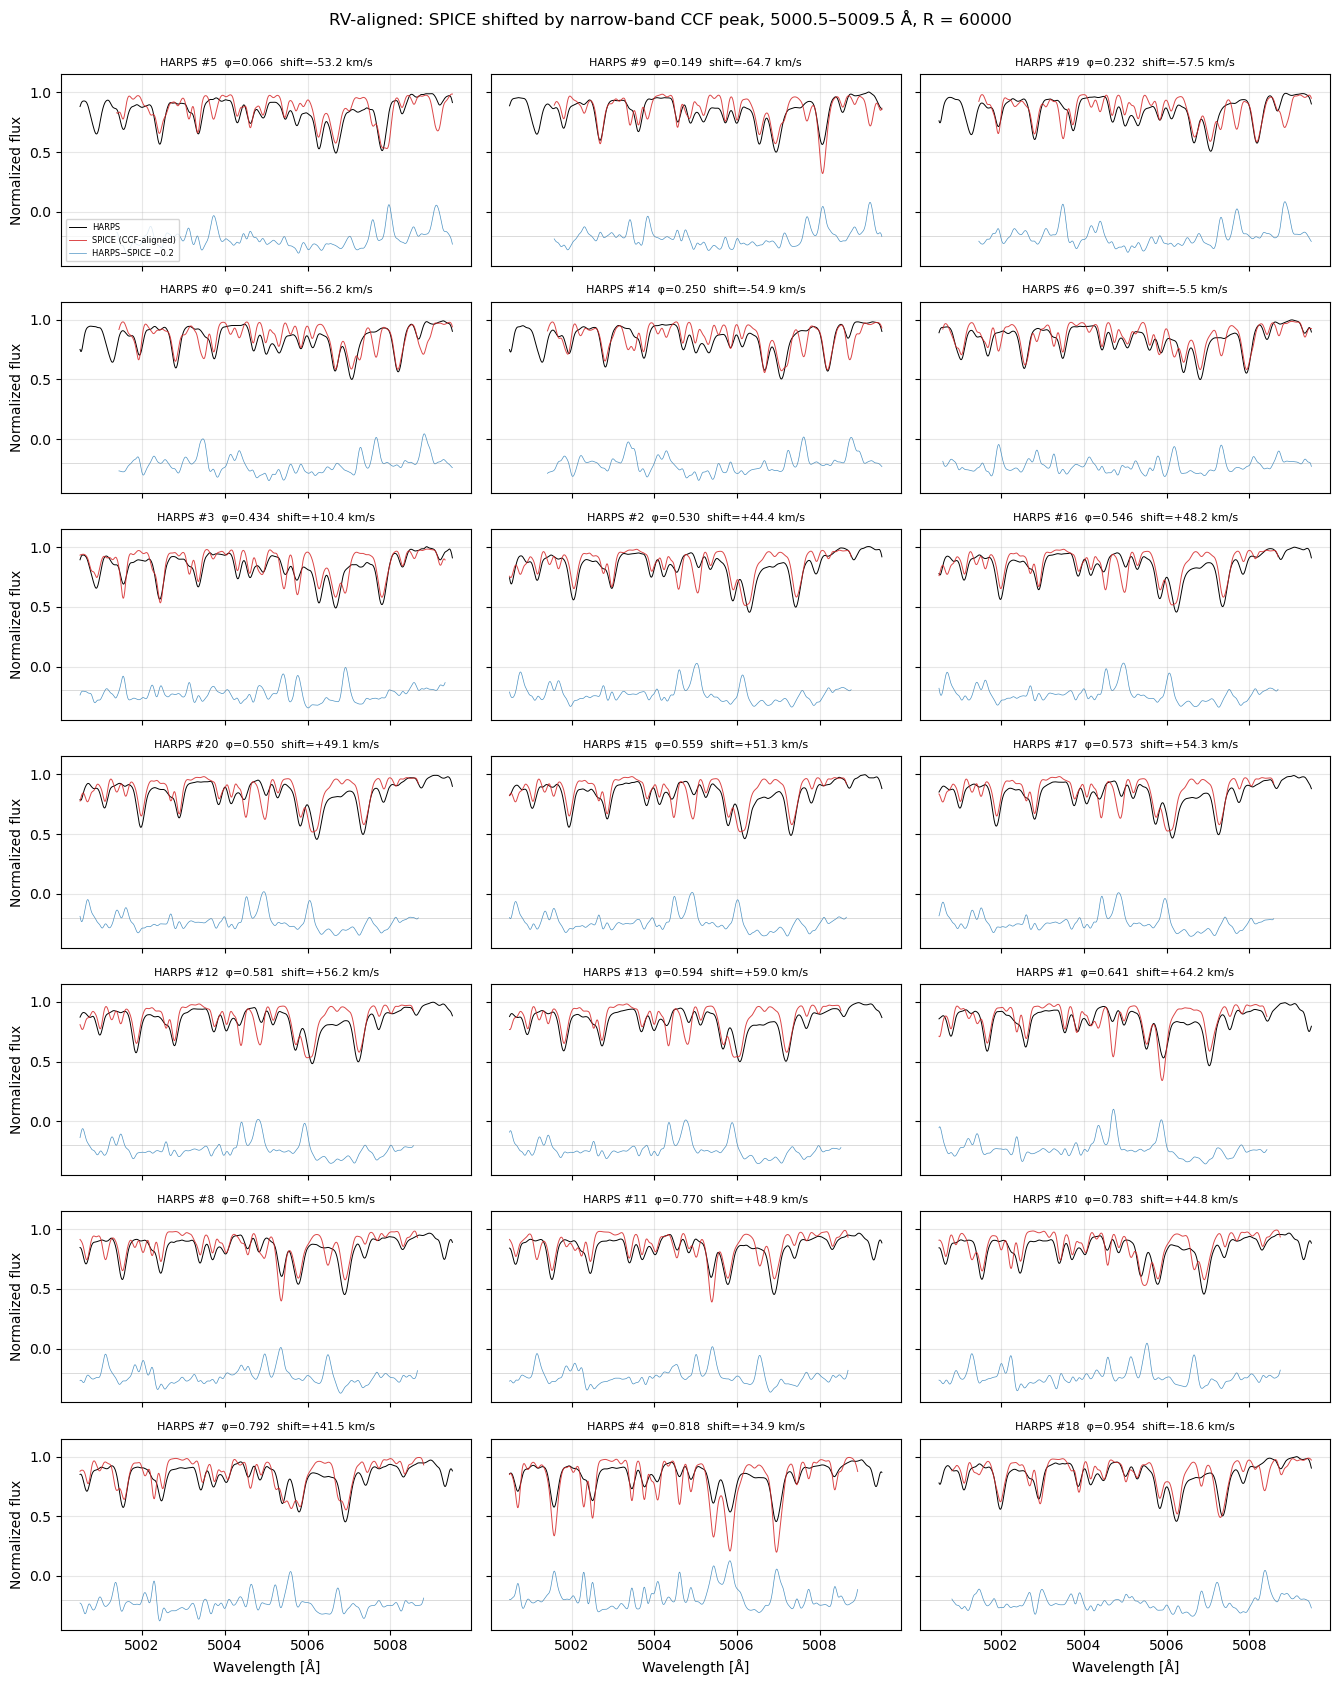

In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 2.4 * n_rows),
                         sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for ax_idx, i in enumerate(order):
    ax = axes.flat[ax_idx]
    h = harps_grid[i]
    s = spice_grid_aligned[i]
    r = h - s
    ax.plot(WAVE, h, color="black", lw=0.7, label="HARPS")
    ax.plot(WAVE, s, color="tab:red", lw=0.7, alpha=0.85, label="SPICE (CCF-aligned)")
    ax.plot(WAVE, r - 0.2, color="tab:blue", lw=0.5, alpha=0.8, label="HARPS−SPICE −0.2")
    ax.axhline(-0.2, color="gray", lw=0.4, alpha=0.5)
    ax.set_title(
        f"HARPS #{i}  φ={HARPS_PHASES[i]:.3f}  shift={-peaks_kms[i]:+.1f} km/s",
        fontsize=8,
    )
    ax.set_ylim(-0.45, 1.15)
    ax.grid(alpha=0.3)
    if ax_idx == 0:
        ax.legend(fontsize=6, loc="lower left")

for j in range(n_panels, axes.size):
    axes.flat[j].axis("off")

for ax in axes[-1]:
    ax.set_xlabel("Wavelength [Å]")
for ax in axes[:, 0]:
    ax.set_ylabel("Normalized flux")

plt.suptitle(
    f"RV-aligned: SPICE shifted by narrow-band CCF peak, {WIN_LO:.1f}–{WIN_HI:.1f} Å, "
    f"R = {R_DEGRADE:.0f}",
    y=1.0,
)
plt.tight_layout()
plt.show()

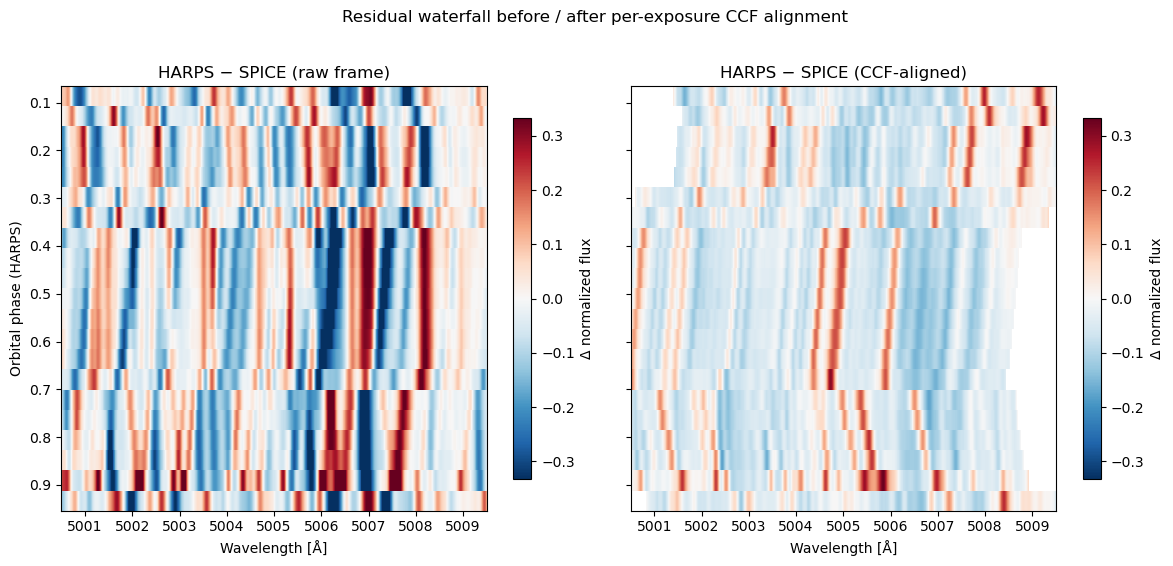

In [10]:
# Side-by-side waterfall: raw vs RV-aligned residuals (phase-sorted).
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
R_raw = residual_raw[order_phase]
R_aln = residual_aligned[order_phase]
vmax = float(np.nanpercentile(np.abs(np.concatenate([R_raw.ravel(), R_aln.ravel()])), 98))
extent = (WIN_LO, WIN_HI, phases_sorted[-1], phases_sorted[0])

for ax, data, title in [
    (axes[0], R_raw, "HARPS − SPICE (raw frame)"),
    (axes[1], R_aln, "HARPS − SPICE (CCF-aligned)"),
]:
    im = ax.imshow(data, aspect="auto", extent=extent, cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, interpolation="nearest")
    ax.set_xlabel("Wavelength [Å]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.85, label="Δ normalized flux")

axes[0].set_ylabel("Orbital phase (HARPS)")
plt.suptitle("Residual waterfall before / after per-exposure CCF alignment", y=1.02)
plt.tight_layout()
plt.show()

## Single-line zoom: Fe I 5006.119 Å and 5007.270 Å

The two strongest features in this window. Plotted as phase-sorted overlays so any
phase-dependent line-shape mismatch (depth, asymmetry, position) is immediately visible.

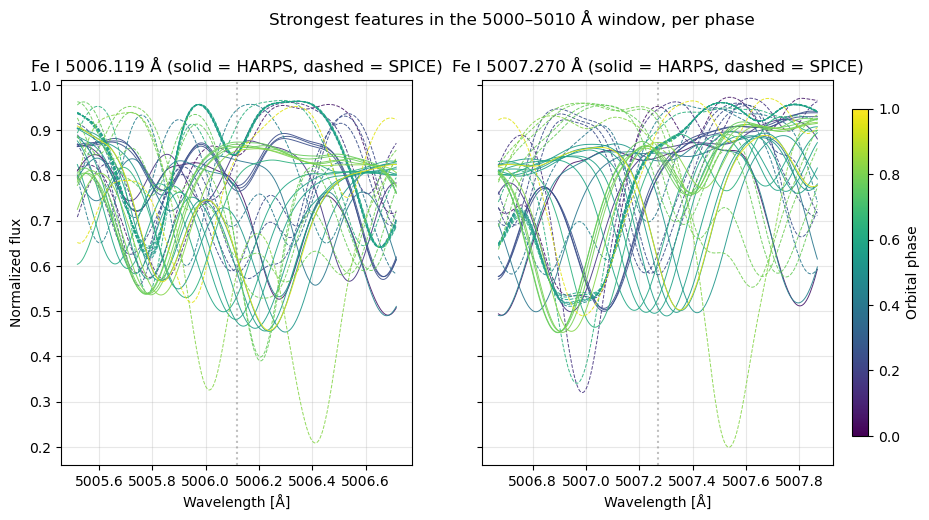

Per-line core-depth statistics (1 − min flux in ±0.3 Å window):
  Fe I 5006.119: HARPS depth = 0.443 ± 0.105, SPICE depth = 0.430 ± 0.111, <HARPS−SPICE> = +0.013
  Fe I 5007.270: HARPS depth = 0.456 ± 0.105, SPICE depth = 0.463 ± 0.121, <HARPS−SPICE> = -0.008


In [11]:
LINES = [("Fe I 5006.119", 5006.119), ("Fe I 5007.270", 5007.270)]
HALF_WIDTH_A = 0.6
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, len(LINES), figsize=(6 * len(LINES), 5), sharey=True)

for ax, (name, lam) in zip(np.atleast_1d(axes), LINES):
    mask = (WAVE >= lam - HALF_WIDTH_A) & (WAVE <= lam + HALF_WIDTH_A)
    if not mask.any():
        ax.text(0.5, 0.5, f"{name}\noutside window", transform=ax.transAxes,
                ha="center", va="center")
        continue
    for i in order_phase:
        c = cmap(HARPS_PHASES[i])
        ax.plot(WAVE[mask], harps_grid[i][mask], color=c, lw=0.7, alpha=0.9)
        ax.plot(WAVE[mask], spice_grid[i][mask], color=c, lw=0.7, alpha=0.9, ls="--")
    ax.axvline(lam, color="gray", ls=":", alpha=0.5)
    ax.set_title(f"{name} Å (solid = HARPS, dashed = SPICE)")
    ax.set_xlabel("Wavelength [Å]")
    ax.grid(alpha=0.3)

axes.flat[0].set_ylabel("Normalized flux")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.85, location="right", pad=0.02)
cbar.set_label("Orbital phase")

plt.suptitle("Strongest features in the 5000–5010 Å window, per phase", y=1.02)
plt.show()

print("Per-line core-depth statistics (1 − min flux in ±0.3 Å window):")
for name, lam in LINES:
    mask = (WAVE >= lam - 0.3) & (WAVE <= lam + 0.3)
    if not mask.any():
        continue
    dh = 1.0 - harps_grid[:, mask].min(axis=1)
    ds = 1.0 - spice_grid[:, mask].min(axis=1)
    print(f"  {name}: HARPS depth = {dh.mean():.3f} ± {dh.std():.3f}, "
          f"SPICE depth = {ds.mean():.3f} ± {ds.std():.3f}, "
          f"<HARPS−SPICE> = {(dh - ds).mean():+.3f}")